# Random Forest on Breast Cancer Dataset
- Random Forest is an ensemble machine learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.
- Instead of relying on a single tree, Random Forest builds many trees and combines their predictions.

## Import Libraries

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Load DataSet

In [2]:
data = load_breast_cancer()

In [3]:
X = data.data
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [4]:
y = data.target
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [5]:
feature_names = data.feature_names
feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [6]:
class_names = data.target_names
class_names

array(['malignant', 'benign'], dtype='<U9')

## Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 398
Testing Samples: 171


## Build Random Forest Model

In [8]:
rf = RandomForestClassifier(
    n_estimators=100,    # Number of trees in the forest
    max_depth=None,      # Maximum depth of each tree.
    bootstrap=True,
    criterion="entropy",
    random_state=42,         # Produces reproducible results.
    n_jobs=-1
)

## Train Model

In [9]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Prediction, Accuracy, Confusion Matrix, Classification Report
A `confusion matrix` compares actual values (rows) with predicted values (columns). Diagonal values represent correct predictions.

**Metrics**

- `Precision`: Measures how many predicted positives are actually positive.
- `Recall`: Measures how many actual positives are correctly identified.
- `F1 Score`: Harmonic mean of Precision and Recall.
- `Support`: Number of samples belonging to each class.

In [10]:
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Random Forest Performance\n\nAccuracy: {round(acc,4)}")

cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:\n{cm}")

cr= classification_report(y_test,y_pred)
print(f"\nClassification Report:\n{cr}")

Random Forest Performance

Accuracy: 0.9415

Confusion Matrix:
[[ 58   6]
 [  4 103]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        64
           1       0.94      0.96      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



## Feature Importance
Feature importance measures how much each feature contributes to model predictions.

In [11]:
print("Feature Importance (average across all trees)")

for name, imp in sorted(
    zip(
        feature_names,
        rf.feature_importances_
    ),
    key=lambda x:x[1],
    reverse=True
):

    print(f"{name}: {imp:.4f}")

Feature Importance (average across all trees)
worst concave points: 0.1602
worst area: 0.1405
worst perimeter: 0.0855
worst radius: 0.0808
mean radius: 0.0742
mean perimeter: 0.0637
mean concave points: 0.0603
mean concavity: 0.0498
mean area: 0.0417
worst concavity: 0.0359
worst compactness: 0.0246
worst texture: 0.0226
area error: 0.0209
worst smoothness: 0.0157
mean compactness: 0.0137
mean texture: 0.0133
worst symmetry: 0.0132
radius error: 0.0121
perimeter error: 0.0103
worst fractal dimension: 0.0090
concavity error: 0.0088
mean smoothness: 0.0086
compactness error: 0.0060
fractal dimension error: 0.0055
smoothness error: 0.0052
mean symmetry: 0.0046
symmetry error: 0.0037
concave points error: 0.0034
texture error: 0.0032
mean fractal dimension: 0.0031


### Visualization

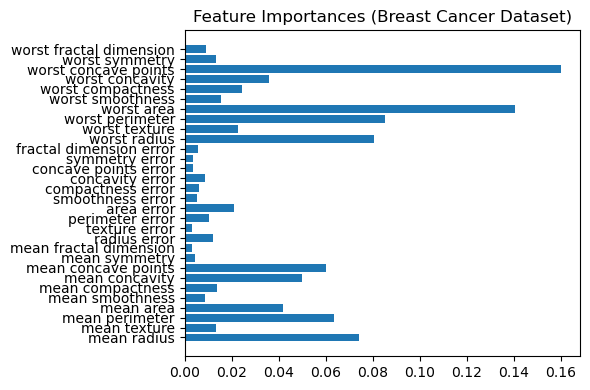

In [12]:
importances = rf.feature_importances_

plt.figure(figsize=(6,4))

plt.barh(
    feature_names,
    importances
)

plt.title(
    "Feature Importances (Breast Cancer Dataset)"
)

plt.tight_layout()

plt.savefig(
    "breast_cancer_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()